<a href="https://colab.research.google.com/github/MythryeeA/Real-Vs-Fake-News-Detection/blob/main/NM_fake_newsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Step 1: Load the individual CSV files
true_df = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')
fake_df = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')

# Step 2: Add a 'label' column to each dataframe
true_df['label'] = 'TRUE'   # Label all true news
fake_df['label'] = 'FAKE'   # Label all fake news

# Step 3: Combine both dataframes into one
news_df = pd.concat([true_df, fake_df], ignore_index=True)

# Step 4: Save the combined dataframe into a new CSV file
news_df.to_csv('news.csv', index=False)

print("Combined and labeled file saved as news.csv")

Combined and labeled file saved as news.csv


In [3]:
df=pd.read_csv('/content/news.csv')
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",TRUE
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",TRUE
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",TRUE
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",TRUE
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",TRUE
...,...,...,...,...,...
3702,Hannity Goes BALLISTIC After Conservative Gro...,It turns out that William F. Buckley s own son...,News,"July 21, 2017",FAKE
3703,WATCH: Kellyanne Conway SMEARS Investigators ...,As Donald Trump s legal team tries to dig up l...,News,"July 21, 2017",FAKE
3704,Florida Republican To Black Voters: ‘If You D...,"Paul Congemi, a Republican candidate running f...",News,"July 21, 2017",FAKE
3705,Corruption: Here’s How Donald Trump Is Breaki...,Presidents are supposed to serve the American ...,News,"July 20, 2017",FAKE


**Data Preprocessing**

In [23]:
df.shape

(3707, 14)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3707 entries, 0 to 3706
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   title            3707 non-null   object        
 1   text             3707 non-null   object        
 2   subject          3707 non-null   object        
 3   date             2899 non-null   datetime64[ns]
 4   label            3707 non-null   int64         
 5   subject_encoded  3707 non-null   int64         
 6   clean_title      3707 non-null   object        
 7   clean_text       3707 non-null   object        
 8   word_count       3707 non-null   int64         
 9   title_length     3707 non-null   int64         
 10  year             2899 non-null   float64       
 11  month            2899 non-null   float64       
 12  day              2899 non-null   float64       
 13  avg_word_length  3707 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(

In [25]:
df.describe()

,date,label,subject_encoded,word_count,title_length,year,month,day,avg_word_length
count,2899,3707.000000,3707.000000,3707.000000,3707.000000,2899.0,2899.000000,2899.000000,3707.000000
mean,2017-09-29 08:25:39.841324544,0.782034,0.782034,252.071756,8.670623,2017.0,9.461883,15.678165,6.331898
min,2017-07-06 00:00:00,0.000000,0.000000,18.000000,4.000000,2017.0,7.000000,1.000000,4.951220
25%,2017-08-15 00:00:00,1.000000,1.000000,125.000000,8.000000,2017.0,8.000000,8.000000,6.074883
50%,2017-10-02 00:00:00,1.000000,1.000000,243.000000,9.000000,2017.0,10.000000,15.000000,6.358025
75%,2017-11-09 00:00:00,1.000000,1.000000,330.500000,10.000000,2017.0,11.000000,24.000000,6.608313
max,2017-12-31 00:00:00,1.000000,1.000000,2993.000000,15.000000,2017.0,12.000000,31.000000,7.716923
std,NaN,0.412920,0.412920,164.824166,1.661347,0.0,1.680126,8.846493,0.404278


In [26]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,808
label,0
subject_encoded,0
clean_title,0
clean_text,0
word_count,0
title_length,0


In [29]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset
df = pd.read_csv("news.csv")

# Display basic structure
print("Initial shape:", df.shape)
print("Columns:", df.columns)

# Step 1: Format the 'date' column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Step 2: Encode the 'label' column (e.g., FAKE -> 0, TRUE -> 1)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# Step 3: Encode the 'subject' column
df['subject_encoded'] = label_encoder.fit_transform(df['subject'])

# Step 4: Define manual stopwords (avoids downloading NLTK resources)
manual_stopwords = {
    'the', 'and', 'is', 'in', 'to', 'of', 'for', 'on', 'with', 'as', 'by',
    'at', 'from', 'that', 'this', 'an', 'it', 'be', 'are', 'was', 'were',
    'or', 'which', 'a', 'but', 'not', 'have', 'has', 'had', 'they', 'their',
    'you', 'i', 'we', 'he', 'she', 'his', 'her', 'them', 'its', 'will', 'would',
    'can', 'could', 'should', 'may', 'might', 'about', 'into', 'over', 'after',
    'before', 'during', 'more', 'most', 'some', 'such', 'no', 'nor', 'only'
}

# Step 5: Define a basic text cleaning function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in manual_stopwords]
    return ' '.join(tokens)

# Step 6: Apply cleaning to 'title' and 'text'
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)

# Step 7: TF-IDF vectorization on the cleaned text
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

# Optional: Check outputs
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print(df[['clean_title', 'clean_text', 'subject_encoded', 'label']].head())


Initial shape: (3707, 5)
Columns: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
TF-IDF matrix shape: (3707, 5000)
                                         clean_title  \
0  us budget fight looms republicans flip fiscal ...   
1  us military accept transgender recruits monday...   
2  senior us republican senator let mr mueller do...   
3  fbi russia probe helped australian diplomat ti...   
4  trump wants postal service charge much amazon ...   

                                          clean_text  subject_encoded  label  
0  washington reuters head conservative republica...                1      1  
1  washington reuters transgender people allowed ...                1      1  
2  washington reuters special counsel investigati...                1      1  
3  washington reuters trump campaign adviser geor...                1      1  
4  seattlewashington reuters president donald tru...                1      1  


**Feature Engineering**

**Model Building**

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy: 0.9784366576819407
Precision: 0.9751243781094527
Recall: 0.99830220713073
F1-score: 0.9865771812080537
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.95       153
           1       0.98      1.00      0.99       589

    accuracy                           0.98       742
   macro avg       0.98      0.95      0.97       742
weighted avg       0.98      0.98      0.98       742



In [31]:
print("Train Accuracy:", log_model.score(X_train, y_train))
print("Test Accuracy:", log_model.score(X_test, y_test))


Train Accuracy: 0.9922428330522766
Test Accuracy: 0.9784366576819407


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


=== Decision Tree Classifier ===
Accuracy: 0.9932614555256065
Precision: 0.9965457685664939
Recall: 0.9948275862068966
F1-score: 0.9956859361518551

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       162
           1       1.00      0.99      1.00       580

    accuracy                           0.99       742
   macro avg       0.99      0.99      0.99       742
weighted avg       0.99      0.99      0.99       742



In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_matrix
y = df['label']

# Train-test split (if not already done)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


=== Random Forest Classifier ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       162
           1       1.00      1.00      1.00       580

    accuracy                           1.00       742
   macro avg       1.00      1.00      1.00       742
weighted avg       1.00      1.00      1.00       742



In [34]:
#saving the model
import joblib
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

**Visualization of Results & Model Insights**

In [ ]:
#importing necessary dependencies
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import numpy as np
import pandas as pd


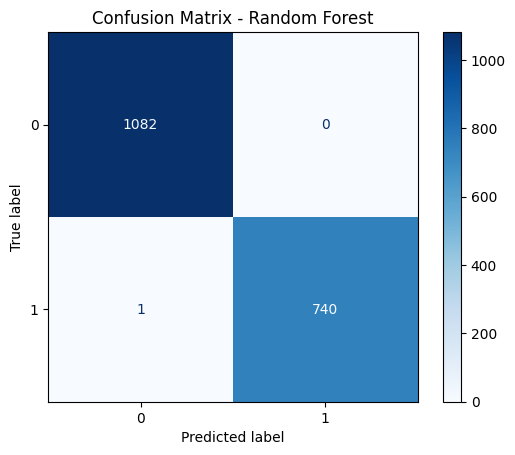

In [ ]:
#Using plots and charts to explain model behavior
#confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

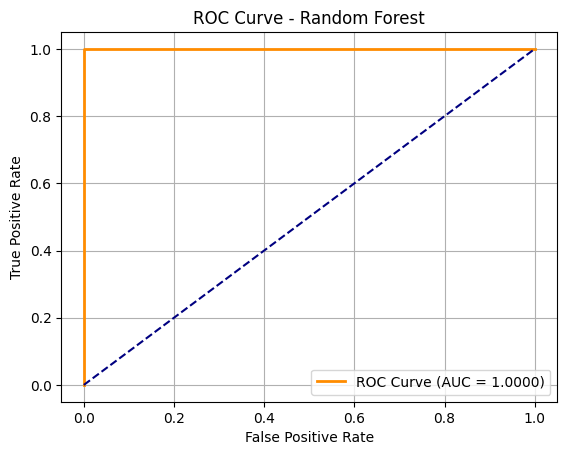

In [ ]:
#ROC curve
from sklearn.metrics import roc_curve, auc
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

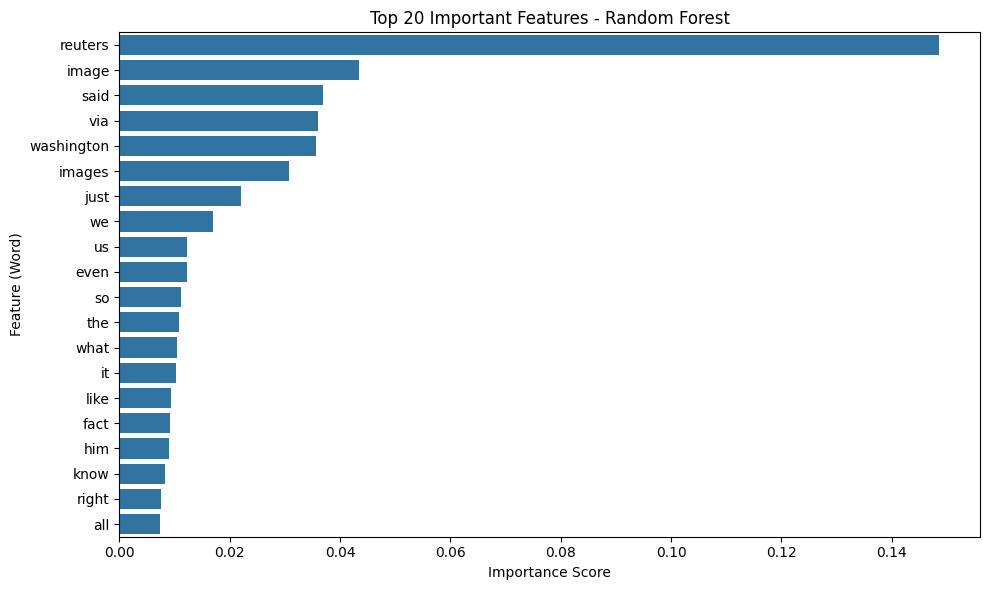

In [ ]:
#Feature Importance Plot
importances = rf_model.feature_importances_
# Corrected the variable name from 'vectorizer' to 'tfidf_vectorizer'
feature_names = tfidf_vectorizer.get_feature_names_out()
# Top 20 important features
indices = np.argsort(importances)[-20:][::-1]
top_features = [feature_names[i] for i in indices]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=top_features)
plt.title("Top 20 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature (Word)")
plt.tight_layout()
plt.show()

<ipython-input-17-a9ae0840a7a4>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette="viridis")


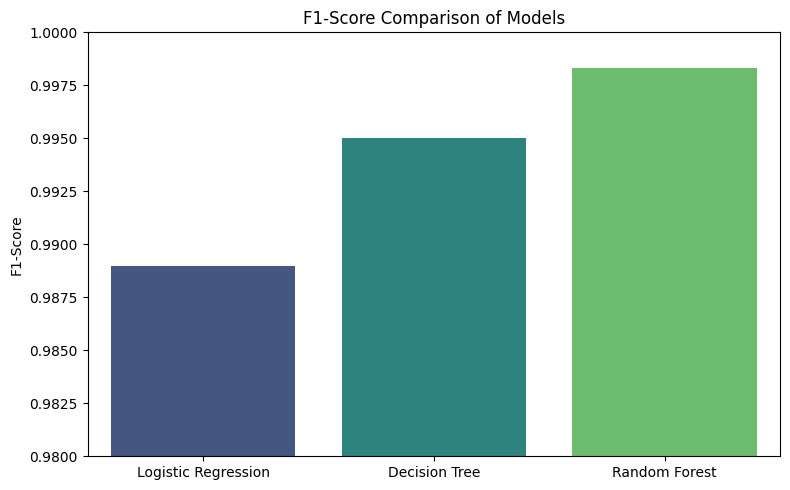

In [ ]:
#Model Performance Comparison (Bar Chart)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
f1_scores = [0.9890, 0.9950, 0.9983]
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=f1_scores, palette="viridis")
plt.title("F1-Score Comparison of Models")
plt.ylabel("F1-Score")
plt.ylim(0.98, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# Print Top 10 Features with highest importance
for i in range(10):
    print(f"{i+1}. {top_features[i]} - Importance Score: {importances[indices[i]]:.4f}")

1. reuters - Importance Score: 0.1486
2. image - Importance Score: 0.0433
3. said - Importance Score: 0.0369
4. via - Importance Score: 0.0360
5. washington - Importance Score: 0.0356
6. images - Importance Score: 0.0307
7. just - Importance Score: 0.0221
8. we - Importance Score: 0.0170
9. us - Importance Score: 0.0123
10. even - Importance Score: 0.0122


**Exploratory Data Analysis(EDA)**

<ipython-input-19-e2f128baccb4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='coolwarm')


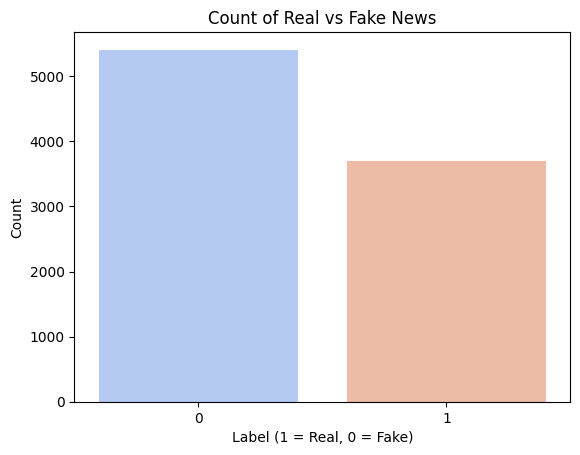

In [ ]:
# 1. Univariate Analysis:
#a) Target Variable Distribution
# Distribution of real vs fake
sns.countplot(data=df, x='label', palette='coolwarm')
plt.title('Count of Real vs Fake News')
plt.xlabel('Label (1 = Real, 0 = Fake)')
plt.ylabel('Count')
plt.show()

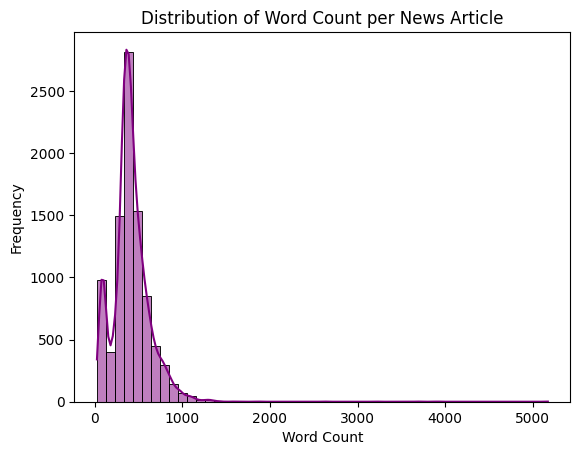

In [ ]:
#b) Word Count per Article
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Word Count per News Article')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

<ipython-input-21-3d1d4d43d846>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', palette='Set2')


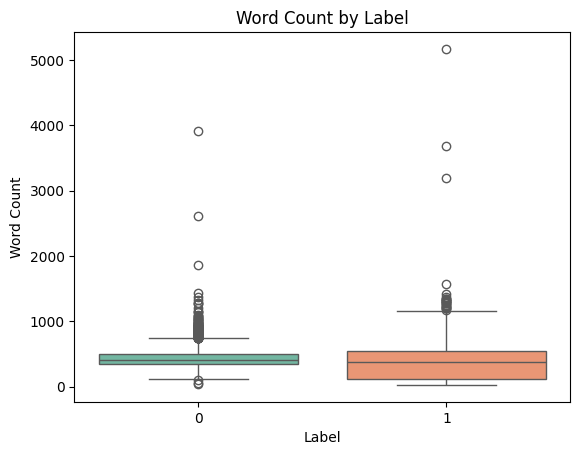

In [ ]:
#c) Boxplot of Word Count
sns.boxplot(data=df, x='label', y='word_count', palette='Set2')
plt.title('Word Count by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.show()

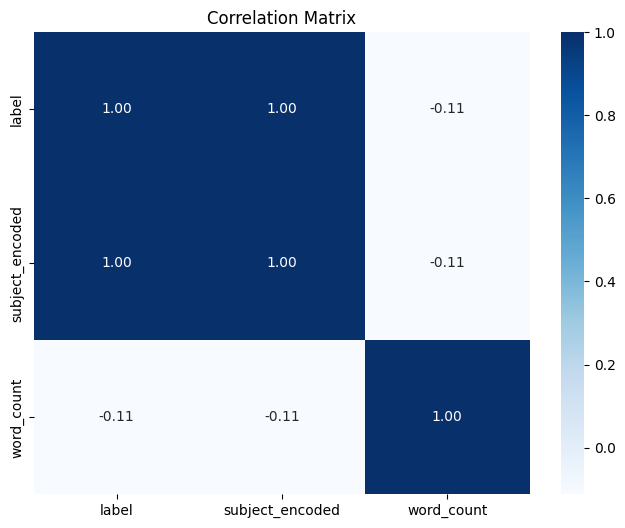

In [ ]:
#2. Bivariate / Multivariate Analysis
#a) Correlation Matrix (Numerical features)
# For numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**Semi Supervised Learning**

In [42]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset
df = pd.read_csv("/content/news.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dropna(subset=["title", "text", "label"], inplace=True)

# 2. Label Encoding (FAKE = 0, TRUE = 1)
df['label'] = df['label'].map({"FAKE": 0, "TRUE": 1})

# 3. Text Cleaning Function
def clean_text(text):
    manual_stopwords = {
        'the','and','is','in','to','of','for','on','with','as','by','at','from',
        'that','this','an','it','be','are','was','were','or','which','a','but',
        'not','have','has','had','they','their','you','i','we','he','she','his',
        'her','them','its','will','would','can','could','should','may','might',
        'about','into','over','after','before','during','more','most','some','such',
        'no','nor','only'
    }
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in manual_stopwords]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

# 4. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_all = tfidf.fit_transform(df['clean_text'])

y_all = df['label'].values

# 5. Split labeled and unlabeled data
X_train_labeled, X_test, y_train_labeled, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

# Further split training data to create unlabeled pool
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(X_train_labeled, y_train_labeled, test_size=0.6, stratify=y_train_labeled, random_state=42)

# Create combined dataset with unlabeled labels as -1
y_combined = np.concatenate([y_labeled, [-1] * len(y_unlabeled)])
X_combined = np.vstack([X_labeled.toarray(), X_unlabeled.toarray()])

# 6. Define base model
base_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 7. Self-training with high threshold
self_training_model = SelfTrainingClassifier(base_model,criterion='threshold',threshold=0.95)

# 8. Fit the model
self_training_model.fit(X_combined, y_combined)

# 9. Evaluate
# Evaluate base model (trained only on labeled data)
base_model.fit(X_labeled, y_labeled)
y_pred_base = base_model.predict(X_test)
y_pred_self = self_training_model.predict(X_test)

print("✅ Supervised Accuracy (before self-training):", round(accuracy_score(y_test, y_pred_base), 4))
print("✅ Semi-Supervised Accuracy (after self-training):", round(accuracy_score(y_test, y_pred_self), 4))
print("\n🧾 Classification Report (Semi-Supervised):\n")
print(classification_report(y_test, y_pred_self))


✅ Supervised Accuracy (before self-training): 0.9973
✅ Semi-Supervised Accuracy (after self-training): 0.996

🧾 Classification Report (Semi-Supervised):

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       162
           1       0.99      1.00      1.00       580

    accuracy                           1.00       742
   macro avg       1.00      0.99      0.99       742
weighted avg       1.00      1.00      1.00       742



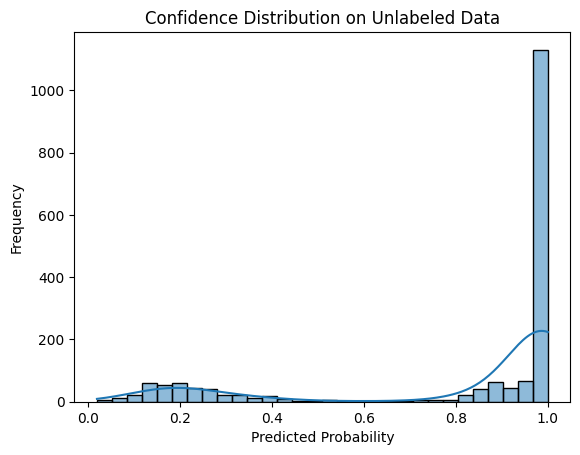

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(self_training_model.predict_proba(X_unlabeled)[:, 1], bins=30, kde=True)
plt.title("Confidence Distribution on Unlabeled Data")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()


In [44]:
print("Number of pseudo-labeled samples used:", (self_training_model.labeled_iter_[-1]))


Number of pseudo-labeled samples used: 1


In [45]:
#Report High-Confidence Sample Count
high_conf = np.sum((probs < 0.2) | (probs > 0.8))
total = len(probs)
print(f"High-confidence pseudo-labels: {high_conf} / {total} ({high_conf/total:.2%})")

High-confidence pseudo-labels: 2466 / 2966 (83.14%)


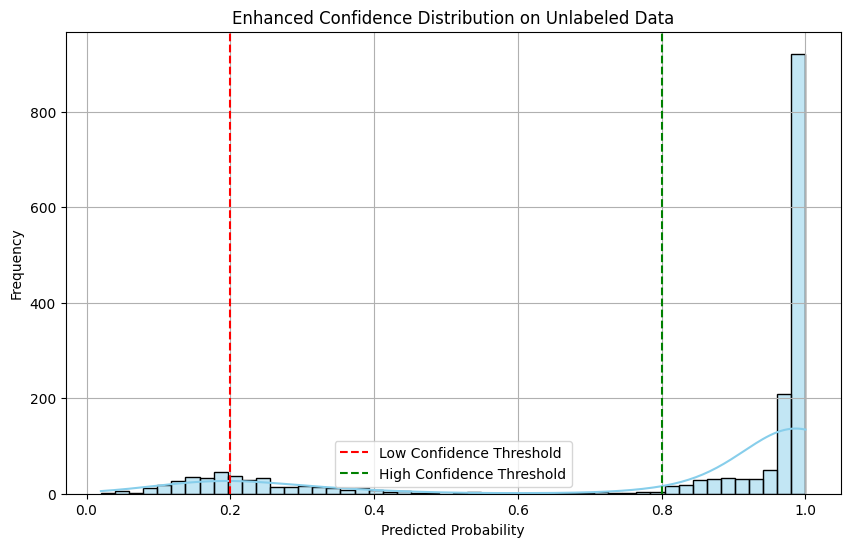

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
probs = self_training_model.predict_proba(X_unlabeled)[:, 1]
sns.histplot(probs, bins=50, kde=True, color='skyblue')
plt.axvline(x=0.2, color='red', linestyle='--', label='Low Confidence Threshold')
plt.axvline(x=0.8, color='green', linestyle='--', label='High Confidence Threshold')
plt.title("Enhanced Confidence Distribution on Unlabeled Data")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

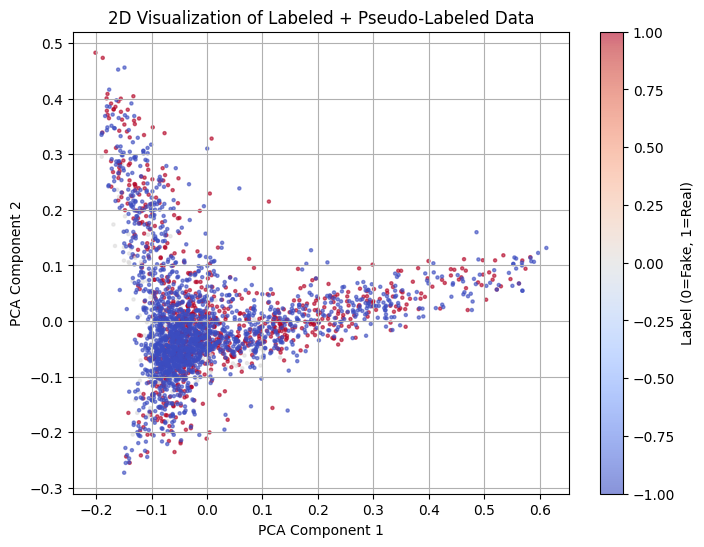

In [48]:
#Add PCA for Visualization
from sklearn.decomposition import PCA
# Remove .toarray() since X_combined is already a numpy array
X_2D = PCA(n_components=2).fit_transform(X_combined)

plt.figure(figsize=(8,6))
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y_combined, cmap='coolwarm', s=5, alpha=0.6)
plt.title("2D Visualization of Labeled + Pseudo-Labeled Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Label (0=Fake, 1=Real)")
plt.grid(True)
plt.show()